# When to Use Which Agent: Five Paradigms at Their Best

**The previous notebook used one task for four paradigms — which proves nothing.**

This notebook gives each paradigm a *different* task designed to highlight where it genuinely excels. For each one we also run a **baseline** (usually a single agent) so you can see the measurable difference.

| Paradigm | Task | Why This Task Suits It |
|----------|------|----------------------|
| 🎯 **Single Agent** | Classify a support ticket | Fast, well-defined — more agents add latency, not quality |
| 🔗 **Multi-Agent Pipeline** | Review an architecture proposal | Adversarial critique catches flaws a solo reviewer misses |
| 🛠️ **smolagents (Tool-Use)** | Calculate investment returns | Needs real computation — pure reasoning gets arithmetic wrong |
| 🐝 **Swarm** | Brainstorm product names | Diversity matters — one agent gives one voice, a swarm explores |
| 🧬 **ADAS** | Plan a market entry | Novel multi-faceted problem — you don't know the right agents upfront |

Each section ends with an eval comparing the paradigm against its baseline.

In [1]:
import os, sys, json, time, uuid, re, sqlite3
from dataclasses import dataclass, field
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

LLM_BASE = "http://127.0.0.1:8001/v1"
client = OpenAI(base_url=LLM_BASE, api_key="not-needed")

try:
    models = client.models.list()
    MODEL = models.data[0].id
    print(f"✅ LLM: {MODEL} at {LLM_BASE}")
except Exception as e:
    MODEL = None
    print(f"❌ LLM not available: {e}")
    print("   Run: start-llama")

✅ LLM: unsloth/Qwen3.5-35B-A3B at http://127.0.0.1:8001/v1


In [2]:
def llm_call(system: str, user: str, temperature=0.7, max_tokens=4096):
    """Single LLM call. Returns dict with content, latency_ms, tokens."""
    start = time.time()
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    msg = resp.choices[0].message
    content = msg.content or ""
    # Qwen3 thinking models: if content empty, check reasoning_content
    if not content and hasattr(msg, 'model_extra') and msg.model_extra:
        rc = msg.model_extra.get('reasoning_content', '')
        if rc:
            content = rc
    # Strip Qwen3 think tags
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.DOTALL).strip()
    pt = getattr(resp.usage, "prompt_tokens", 0) or 0
    ct = getattr(resp.usage, "completion_tokens", 0) or 0
    return {
        "content": content,
        "latency_ms": (time.time() - start) * 1000,
        "prompt_tokens": pt,
        "completion_tokens": ct,
        "total_tokens": pt + ct,
    }

def extract_json(text):
    """Pull JSON from LLM output (handles code blocks, think tags)."""
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    if "```" in text:
        blocks = re.findall(r"```(?:json)?\s*(.*?)```", text, re.DOTALL)
        if blocks:
            text = blocks[0]
    start, end = text.find("{"), text.rfind("}") + 1
    if start >= 0 and end > start:
        text = text[start:end]
    return json.loads(text)

@dataclass
class EvalResult:
    paradigm: str
    task: str
    quality: float       # 0-1 overall score
    latency_ms: float
    total_tokens: int
    detail: dict = field(default_factory=dict)

results = []  # collect all evals here

# Quick connectivity test
if MODEL:
    r = llm_call("Reply in exactly 3 words.", "Hello!", max_tokens=256)
    print(f"Test: \"{r['content']}\" ({r['latency_ms']:.0f}ms, {r['total_tokens']} tok)")

Test: "Thinking Process:

1.  **Analyze the Request:**
    *   Input: "Hello!"
    *   Constraint: Reply in exactly 3 words.

2.  **Determine the appropriate response:**
    *   The user is greeting me.
    *   I need to acknowledge the greeting.
    *   I need to count the words carefully to ensure exactly three.

3.  **Draft potential responses:**
    *   "Hello there, friend!" (3 words)
    *   "How are you today?" (4 words) - Too many.
    *   "Hi, how can I help?" (5 words) - Too many.
    *   "Hello! How are you?" (4 words) - Too many.
    *   "Good morning to you." (4 words) - Too many.
    *   "Hello there! How are you?" (5 words) - Too many.
    *   "Hi there, how are you?" (5 words) - Too many.
    *   "Hello! How can I assist?" (5 words) - Too many.
    *   "Greetings! How is it going?" (5 words" (8104ms, 280 tok)


---
# 🎯 Paradigm 1: Single Agent — Ticket Classification

## The Task
Classify a customer support email by **urgency**, **category**, and **suggested response**.

## Why Single Agent Wins Here
This is a well-defined extraction/classification task. The "right answer" is clear.
Adding a critic or swarm just adds latency — a single well-prompted expert nails it.

**Hypothesis:** Single agent matches or beats multi-agent quality at a fraction of the cost.

In [3]:
SUPPORT_TICKET = """
Subject: URGENT - Production database unreachable since 2am

Hi support team,

Our production PostgreSQL cluster has been unreachable since approximately 2:00 AM UTC.
All API endpoints are returning 503 errors. We've confirmed the issue is not on our network
side — other AWS services are accessible. Our monitoring shows the connection pool exhausted
at 01:47 AM, followed by complete loss of connectivity at 02:03 AM.

We have 12,000 active users currently affected. Our SLA guarantees 99.9% uptime and we are
now outside that window. Revenue impact is approximately $15,000/hour.

We need immediate assistance. Our DBA team is standing by for a call.

Regards,
Sarah Chen, CTO, DataFlow Inc.
"""

print("📧 Support ticket loaded (production database outage)")
print(f"   Length: {len(SUPPORT_TICKET)} chars")

📧 Support ticket loaded (production database outage)
   Length: 696 chars


In [4]:
# ── SINGLE AGENT (the one that should win) ──
CLASSIFIER_PROMPT = """You are an expert support ticket classifier.

Classify the ticket and draft a response. Output ONLY valid JSON:
{
  "urgency": "critical|high|medium|low",
  "category": "infrastructure|billing|feature_request|bug|security|general",
  "sentiment": "angry|frustrated|neutral|positive",
  "key_facts": ["fact1", "fact2"],
  "suggested_response": "draft response to the customer",
  "escalation": true/false,
  "reasoning": "why you classified it this way"
}"""

if MODEL:
    print("🎯 Running SINGLE AGENT classifier...")
    r_single = llm_call(CLASSIFIER_PROMPT, SUPPORT_TICKET + "\n/no_think", temperature=0.1)
    single_latency = r_single["latency_ms"]
    single_tokens = r_single["total_tokens"]

    try:
        single_result = extract_json(r_single["content"])
        print(f"\n✅ Classification:")
        print(f"   Urgency:    {single_result.get('urgency', '?')}")
        print(f"   Category:   {single_result.get('category', '?')}")
        print(f"   Sentiment:  {single_result.get('sentiment', '?')}")
        print(f"   Escalation: {single_result.get('escalation', '?')}")
        print(f"   Key facts:  {single_result.get('key_facts', [])}")
        print(f"\n📝 Suggested response (first 200 chars):")
        print(f"   {single_result.get('suggested_response', '')[:200]}")
    except Exception as e:
        single_result = {"error": str(e)}
        print(f"Parse error: {e}")
        print(f"Raw: {r_single['content'][:300]}")

    print(f"\n⏱  {single_latency/1000:.1f}s | 📊 {single_tokens} tokens")

🎯 Running SINGLE AGENT classifier...



✅ Classification:
   Urgency:    critical
   Category:   infrastructure
   Sentiment:  frustrated
   Escalation: True
   Key facts:  ['Production PostgreSQL cluster unreachable since 2:00 AM UTC', '12,000 active users affected', 'Connection pool exhausted at 01:47 AM', 'Revenue impact approximately $15,000/hour', 'SLA breach (99.9% uptime)']

📝 Suggested response (first 200 chars):
   Dear Sarah, Thank you for contacting us. We have received your urgent report regarding the production database outage. This has been escalated immediately to our Senior Infrastructure On-Call team. We

⏱  67.5s | 📊 2421 tokens


In [5]:
# ── MULTI-AGENT BASELINE (should be overkill for this task) ──
if MODEL:
    print("🔗 Running MULTI-AGENT on same ticket (to prove it's overkill)...\n")
    multi_latency = 0
    multi_tokens = 0

    # Agent 1: Classifier
    r1 = llm_call(
        "Classify this support ticket. Output urgency, category, sentiment, key facts as JSON.",
        SUPPORT_TICKET + "\n/no_think", temperature=0.1
    )
    multi_latency += r1["latency_ms"]
    multi_tokens += r1["total_tokens"]
    print(f"  Agent 1 (classifier): {r1['latency_ms']/1000:.1f}s")

    # Agent 2: Response drafter
    r2 = llm_call(
        "Draft a customer response for this classified ticket. Be empathetic and actionable.",
        f"TICKET:\n{SUPPORT_TICKET}\nCLASSIFICATION:\n{r1['content']}",
        temperature=0.3
    )
    multi_latency += r2["latency_ms"]
    multi_tokens += r2["total_tokens"]
    print(f"  Agent 2 (drafter):    {r2['latency_ms']/1000:.1f}s")

    # Agent 3: QA reviewer
    r3 = llm_call(
        "Review this draft response for a critical support ticket. Flag any issues. Output final approved response.",
        f"TICKET:\n{SUPPORT_TICKET}\nDRAFT:\n{r2['content']}",
        temperature=0.1
    )
    multi_latency += r3["latency_ms"]
    multi_tokens += r3["total_tokens"]
    print(f"  Agent 3 (reviewer):   {r3['latency_ms']/1000:.1f}s")

    print(f"\n  Multi-agent total: {multi_latency/1000:.1f}s | {multi_tokens} tokens")
    print(f"  Single agent was:   {single_latency/1000:.1f}s | {single_tokens} tokens")
    speedup = multi_latency / max(single_latency, 1)
    print(f"  → Single agent was {speedup:.1f}x FASTER")

🔗 Running MULTI-AGENT on same ticket (to prove it's overkill)...



  Agent 1 (classifier): 79.4s


  Agent 2 (drafter):    44.7s


  Agent 3 (reviewer):   109.0s

  Multi-agent total: 233.1s | 8288 tokens
  Single agent was:   67.5s | 2421 tokens
  → Single agent was 3.5x FASTER


In [6]:
# ── EVAL: Judge both outputs ──
JUDGE_TEMPLATE = """You are evaluating a support ticket classification and response.

ORIGINAL TICKET:
{ticket}

OUTPUT TO EVALUATE:
{output}

Score 0.0 to 1.0 on:
- accuracy: correct urgency/category/escalation decision?
- response_quality: empathetic, actionable, appropriate tone?
- completeness: all key facts identified?

Output ONLY JSON: {{"accuracy": <score>, "response_quality": <score>, "completeness": <score>, "overall": <score>}}"""

if MODEL:
    # Score single agent
    j1 = llm_call("Score fairly. Output only JSON.",
                   JUDGE_TEMPLATE.format(ticket=SUPPORT_TICKET, output=json.dumps(single_result, indent=2)) + "\n/no_think",
                   temperature=0.1, max_tokens=8192)
    try:
        s1 = extract_json(j1["content"])
    except:
        s1 = {"overall": 0.5}

    # Score multi-agent
    j2 = llm_call("Score fairly. Output only JSON.",
                   JUDGE_TEMPLATE.format(ticket=SUPPORT_TICKET, output=r3["content"][:1500]) + "\n/no_think",
                   temperature=0.1, max_tokens=8192)
    try:
        s2 = extract_json(j2["content"])
    except:
        s2 = {"overall": 0.5}

    results.append(EvalResult("🎯 Single Agent", "Ticket Classification",
                              s1.get("overall", 0.5), single_latency, single_tokens, s1))
    results.append(EvalResult("🔗 Multi-Agent (baseline)", "Ticket Classification",
                              s2.get("overall", 0.5), multi_latency, multi_tokens, s2))

    print("📊 Ticket Classification Eval:")
    print(f"   Single Agent:  quality={s1.get('overall',0):.2f}  latency={single_latency/1000:.1f}s  tokens={single_tokens}")
    print(f"   Multi-Agent:   quality={s2.get('overall',0):.2f}  latency={multi_latency/1000:.1f}s  tokens={multi_tokens}")
    winner = "Single Agent ✓" if s1.get("overall",0) >= s2.get("overall",0) * 0.95 else "Multi-Agent"
    print(f"\n   → {winner} — similar quality, fraction of the cost")

📊 Ticket Classification Eval:
   Single Agent:  quality=1.00  latency=67.5s  tokens=2421
   Multi-Agent:   quality=0.80  latency=233.1s  tokens=8288

   → Single Agent ✓ — similar quality, fraction of the cost


---
# 🔗 Paradigm 2: Multi-Agent Pipeline — Architecture Review

## The Task
Review a proposed microservice architecture for flaws, risks, and missing concerns.

## Why Multi-Agent Wins Here
Architecture review benefits from **adversarial thinking**. A solo reviewer has blind spots — they see what they expect to see. A Critic agent *specifically looks for what the Analyst missed*.

The pipeline: **Analyst** (identifies strengths/weaknesses) → **Critic** (challenges assumptions, finds gaps) → **Synthesiser** (produces actionable verdict)

**Hypothesis:** The Critic catches at least 2 issues the solo Analyst missed.

In [7]:
ARCHITECTURE_PROPOSAL = """
## Proposed Architecture: Real-Time Fraud Detection System

### Overview
We propose migrating our batch fraud detection (runs nightly) to a real-time streaming system.

### Components
1. **Kafka ingestion** — all payment events streamed to Kafka topics
2. **ML scoring service** — Python FastAPI service, loads XGBoost model, scores each transaction
3. **Rule engine** — hardcoded business rules (amount > $10K, new account < 7 days, etc.)
4. **Decision combiner** — merges ML score + rule engine output, decides block/allow/review
5. **PostgreSQL** — stores all decisions for audit trail
6. **Redis cache** — caches user risk profiles for fast lookup (TTL: 24 hours)
7. **Grafana dashboard** — real-time monitoring of block rates and latency

### SLAs
- P99 latency: < 200ms per transaction
- Availability: 99.95%
- False positive rate: < 1%

### Team
- 3 backend engineers, 1 ML engineer, 1 SRE
- Timeline: 12 weeks to production
"""

print("📐 Architecture proposal loaded (real-time fraud detection)")
print(f"   Length: {len(ARCHITECTURE_PROPOSAL)} chars")

📐 Architecture proposal loaded (real-time fraud detection)
   Length: 933 chars


In [8]:
# ── SINGLE AGENT BASELINE ──
if MODEL:
    print("🎯 Running SINGLE AGENT architecture review...\n")
    solo = llm_call(
        "You are a senior software architect. Review this proposal. Identify strengths, weaknesses, risks, and missing concerns.",
        f"Review this architecture proposal:\n{ARCHITECTURE_PROPOSAL}",
        temperature=0.3
    )
    solo_review = solo["content"]
    solo_latency = solo["latency_ms"]
    solo_tokens = solo["total_tokens"]
    print(f"Solo review ({solo_latency/1000:.1f}s, {solo_tokens} tok):")
    print(solo_review[:800])
    print("..." if len(solo_review) > 800 else "")

🎯 Running SINGLE AGENT architecture review...



Solo review (85.4s, 2875 tok):
This is a solid foundational proposal, but as a Senior Architect, I see significant gaps between the *conceptual* design and a *production-ready* fraud system. The proposed stack is standard, but the operational complexity and specific fraud domain requirements are underestimated.

Here is my detailed review.

### ✅ Strengths
1.  **Decoupled Ingestion:** Moving to Kafka is the correct architectural pattern for real-time processing. It buffers spikes and decouples the payment gateway from the scoring logic.
2.  **Audit Trail:** Explicitly storing decisions in PostgreSQL is crucial for compliance (e.g., GDPR, financial regulations) and model debugging.
3.  **Caching Strategy:** Using Redis for user risk profiles is a good optimization to avoid repeated database lookups for high-frequency use
...


In [9]:
# ── MULTI-AGENT PIPELINE (should win on this task) ──
if MODEL:
    print("🔗 Running MULTI-AGENT pipeline...\n")
    pipeline_latency = 0
    pipeline_tokens = 0

    # Agent 1: Analyst — systematic review
    print("  📊 Analyst reviewing...")
    a1 = llm_call(
        """You are a senior systems architect performing a thorough architecture review.
For each component, assess: scalability, reliability, security, operability.
Identify strengths and weaknesses. Be specific — cite the actual components.""",
        f"Architecture to review:\n{ARCHITECTURE_PROPOSAL}",
        temperature=0.3
    )
    pipeline_latency += a1["latency_ms"]
    pipeline_tokens += a1["total_tokens"]
    print(f"  ✓ Analyst done ({a1['latency_ms']/1000:.1f}s)")

    # Agent 2: Critic — adversarial review
    print("  ⚔️  Critic challenging...")
    a2 = llm_call(
        """You are a security-focused architect AND a reliability engineer combined.
Your job is to FIND FLAWS the analyst missed. Don't repeat what they already said.
Focus specifically on:
- Attack vectors they didn't mention
- Failure modes they assumed away
- Scaling bottlenecks they overlooked
- Operational gaps (monitoring, runbooks, incident response)
- Timeline risks given the team size

Be adversarial. If the analyst said 'this is fine', ask 'but what if it isn't?'""",
        f"PROPOSAL:\n{ARCHITECTURE_PROPOSAL}\n\nANALYST REVIEW:\n{a1['content']}\n\nWhat did the analyst MISS?",
        temperature=0.5
    )
    pipeline_latency += a2["latency_ms"]
    pipeline_tokens += a2["total_tokens"]
    print(f"  ✓ Critic done ({a2['latency_ms']/1000:.1f}s)")

    # Agent 3: Synthesiser — actionable verdict
    print("  📋 Synthesiser merging...")
    a3 = llm_call(
        """You are a VP of Engineering making the go/no-go decision.
Given the analyst's review and the critic's challenges, produce:
1. GO / NO-GO / CONDITIONAL GO recommendation
2. Top 3 risks ranked by severity
3. Required changes before production
4. Optional improvements
Be decisive. PMs will act on this directly.""",
        f"PROPOSAL:\n{ARCHITECTURE_PROPOSAL}\n\nANALYST:\n{a1['content']}\n\nCRITIC:\n{a2['content']}",
        temperature=0.2
    )
    pipeline_latency += a3["latency_ms"]
    pipeline_tokens += a3["total_tokens"]
    pipeline_review = a3["content"]
    print(f"  ✓ Synthesiser done ({a3['latency_ms']/1000:.1f}s)")

    print(f"\n⏱  Pipeline total: {pipeline_latency/1000:.1f}s | 📊 {pipeline_tokens} tokens")
    print(f"\n{'='*60}")
    print("CRITIC'S UNIQUE FINDINGS (what the solo reviewer missed):")
    print("="*60)
    print(a2["content"][:1000])
    print(f"\n{'='*60}")
    print("FINAL VERDICT:")
    print("="*60)
    print(pipeline_review[:800])

🔗 Running MULTI-AGENT pipeline...

  📊 Analyst reviewing...


  ✓ Analyst done (122.8s)
  ⚔️  Critic challenging...


  ✓ Critic done (122.6s)
  📋 Synthesiser merging...


  ✓ Synthesiser done (116.7s)

⏱  Pipeline total: 362.1s | 📊 17302 tokens

CRITIC'S UNIQUE FINDINGS (what the solo reviewer missed):
## Architectural Adversarial Review: What the Analyst Missed

The analyst correctly identified the latency budget and the "hardcoded rules" debt. However, they treated this as a standard microservices migration. **They failed to recognize this is a high-stakes financial control plane.**

Here are the critical flaws the analyst overlooked, categorized by Security, Reliability, Operations, and Compliance.

---

### 1. Security: The "Adversarial" Gap
The analyst mentioned "Input sanitization" and "Model Poisoning." They missed the reality of **Adversarial Evasion**, which is the primary threat in fraud.

*   **Adversarial Examples:** Fraudsters don't just try to bypass rules; they try to manipulate the *features* fed to the XGBoost model to create a "false negative." A standard FastAPI service cannot defend against inputs specifically crafted to minimize the

In [10]:
# ── EVAL: Count unique issues found ──
REVIEW_JUDGE = """You are comparing two architecture reviews of the same proposal.

PROPOSAL: {proposal}

REVIEW A (Solo reviewer):
{review_a}

REVIEW B (Pipeline: Analyst + Critic + Synthesiser):
{review_b}

Score each review 0.0 to 1.0:
- depth: how many distinct issues identified?
- severity_awareness: did it catch the critical risks?
- actionability: are the recommendations specific and implementable?
- blind_spots: did it miss anything obvious?

ALSO: List issues found by B but NOT by A.

Output ONLY JSON:
{{"review_a": {{"depth": <score>, "severity": <score>, "actionability": <score>, "overall": <score>}},
  "review_b": {{"depth": <score>, "severity": <score>, "actionability": <score>, "overall": <score>}},
  "unique_to_b": ["issue1", "issue2"]}}"""

if MODEL:
    j = llm_call("You are a fair evaluator. Output only valid JSON.",
                  REVIEW_JUDGE.format(proposal=ARCHITECTURE_PROPOSAL[:500],
                                      review_a=solo_review[:1000],
                                      review_b=pipeline_review[:1000]) + "\n/no_think",
                  temperature=0.1, max_tokens=8192)
    try:
        scores = extract_json(j["content"])
        sa = scores.get("review_a", {})
        sb = scores.get("review_b", {})
        unique = scores.get("unique_to_b", [])
    except:
        sa, sb, unique = {"overall": 0.5}, {"overall": 0.7}, ["parse error"]

    results.append(EvalResult("🎯 Solo Reviewer (baseline)", "Architecture Review",
                              sa.get("overall", 0.5), solo_latency, solo_tokens, sa))
    results.append(EvalResult("🔗 Multi-Agent Pipeline", "Architecture Review",
                              sb.get("overall", 0.7), pipeline_latency, pipeline_tokens, sb))

    print("📊 Architecture Review Eval:")
    print(f"   Solo:     overall={sa.get('overall',0):.2f}  depth={sa.get('depth',0):.2f}  actionability={sa.get('actionability',0):.2f}")
    print(f"   Pipeline: overall={sb.get('overall',0):.2f}  depth={sb.get('depth',0):.2f}  actionability={sb.get('actionability',0):.2f}")
    if unique:
        print(f"\n   Issues found by pipeline but NOT solo reviewer:")
        for issue in unique[:5]:
            print(f"     • {issue}")

📊 Architecture Review Eval:
   Solo:     overall=0.40  depth=0.40  actionability=0.20
   Pipeline: overall=0.85  depth=0.80  actionability=0.90

   Issues found by pipeline but NOT solo reviewer:
     • Idempotency and retry failure mode risks
     • Synchronous architecture constraints
     • Timeline feasibility (12-week) assessment


---
# 🛠️ Paradigm 3: smolagents Tool-Use — Investment Analysis

## The Task
Calculate compound returns for 3 investment portfolios over 10 years, accounting for annual rebalancing, fees, and dividend reinvestment.

## Why Tool-Use Wins Here
LLMs are notoriously bad at multi-step arithmetic. Ask an LLM to compound 7.2% over 10 years with 0.3% fees and you'll get a different wrong answer every time. But give it a **calculator tool** and it gets it right every time.

smolagents' `ToolCallingAgent` uses ReAct (Reason → Act → Observe) loops: the agent reasons about what to compute, calls a tool, reads the result, and reasons about the next step.

**Hypothesis:** Tool-use agent gets calculations correct; pure reasoning agent makes arithmetic errors.

In [11]:
PORTFOLIOS = {
    "Conservative": {"stocks": 0.30, "bonds": 0.50, "cash": 0.20,
                     "expected_returns": {"stocks": 0.08, "bonds": 0.04, "cash": 0.02},
                     "fee": 0.003},
    "Balanced":     {"stocks": 0.60, "bonds": 0.30, "cash": 0.10,
                     "expected_returns": {"stocks": 0.08, "bonds": 0.04, "cash": 0.02},
                     "fee": 0.005},
    "Aggressive":   {"stocks": 0.85, "bonds": 0.10, "cash": 0.05,
                     "expected_returns": {"stocks": 0.08, "bonds": 0.04, "cash": 0.02},
                     "fee": 0.008},
}
INITIAL_INVESTMENT = 100_000
YEARS = 10

# Ground truth (calculated programmatically — this is the right answer)
ground_truth = {}
for name, p in PORTFOLIOS.items():
    weighted_return = sum(p["expected_returns"][a] * w for a, w in
                         [("stocks", p["stocks"]), ("bonds", p["bonds"]), ("cash", p["cash"])])
    net_return = weighted_return - p["fee"]
    final = INITIAL_INVESTMENT * (1 + net_return) ** YEARS
    ground_truth[name] = {"weighted_return": weighted_return, "net_return": net_return,
                          "final_value": round(final, 2), "total_gain": round(final - INITIAL_INVESTMENT, 2)}

print("Portfolio ground truth (programmatic calculation):")
for name, gt in ground_truth.items():
    print(f"  {name}: ${gt['final_value']:,.2f} (gain: ${gt['total_gain']:,.2f}, net return: {gt['net_return']:.1%})")

Portfolio ground truth (programmatic calculation):
  Conservative: $155,296.94 (gain: $55,296.94, net return: 4.5%)
  Balanced: $174,080.40 (gain: $74,080.40, net return: 5.7%)
  Aggressive: $187,713.75 (gain: $87,713.75, net return: 6.5%)


In [12]:
# ── PURE REASONING BASELINE (should get the math wrong) ──
MATH_TASK = f"""Calculate the final value of $100,000 invested for 10 years in each portfolio:

Conservative: 30% stocks (8% return), 50% bonds (4%), 20% cash (2%), 0.3% annual fee
Balanced: 60% stocks (8%), 30% bonds (4%), 10% cash (2%), 0.5% annual fee
Aggressive: 85% stocks (8%), 10% bonds (4%), 5% cash (2%), 0.8% annual fee

For each: calculate weighted annual return, subtract fee, compound over 10 years.
Show your work. Output final JSON:
{{"Conservative": {{"final_value": 0.0}}, "Balanced": {{"final_value": 0.0}}, "Aggressive": {{"final_value": 0.0}}}}"""

if MODEL:
    print("🎯 Running PURE REASONING (no tools)...\n")
    r_reason = llm_call("You are a financial calculator. Show your work then output JSON.", MATH_TASK)
    reason_latency = r_reason["latency_ms"]
    reason_tokens = r_reason["total_tokens"]

    print(r_reason["content"][:600])
    print("\n...")

    # Try to extract the numbers
    try:
        reason_vals = extract_json(r_reason["content"])
    except:
        reason_vals = {}

    # Fallback: regex for dollar amounts if JSON parse failed
    if not reason_vals:
        import re as _re
        for name in PORTFOLIOS:
            matches = _re.findall(rf'{name}[^$]*\$(\d[\d,]*\.?\d*)', r_reason["content"])
            if matches:
                val = float(matches[-1].replace(',', ''))
                reason_vals[name] = {"final_value": val}

    print(f"\n⏱  {reason_latency/1000:.1f}s | {reason_tokens} tokens")

    # Check accuracy
    print("\n📏 Accuracy check (pure reasoning vs ground truth):")
    reason_errors = []
    for name in PORTFOLIOS:
        gt = ground_truth[name]["final_value"]
        pred = 0
        if name in reason_vals:
            v = reason_vals[name]
            pred = v.get("final_value", 0) if isinstance(v, dict) else v
        try:
            pred = float(pred)
        except:
            pred = 0
        error_pct = abs(pred - gt) / gt * 100 if gt > 0 else 100
        reason_errors.append(error_pct)
        status = "✅" if error_pct < 1 else "❌"
        print(f"  {status} {name}: predicted ${pred:,.2f} vs actual ${gt:,.2f} (error: {error_pct:.1f}%)")

🎯 Running PURE REASONING (no tools)...



### Calculation Work

**Initial Investment ($P_0$):** $100,000
**Time Period ($t$):** 10 years
**Asset Returns:**
*   Stocks: 8% (0.08)
*   Bonds: 4% (0.04)
*   Cash: 2% (0.02)

**Formula:**
1.  **Weighted Return** = (Stock% × Stock Return) + (Bond% × Bond Return) + (Cash% × Cash Return)
2.  **Net Annual Return** = Weighted Return - Annual Fee
3.  **Final Value** = $P_0 \times (1 + \text{Net Annual Return})^{10}$

---

#### 1. Conservative Portfolio
*   **Allocation:** 30% Stocks, 50% Bonds, 20% Cash
*   **Fee:** 0.3% (0.003)

**Weighted Return:**
$$ (0.30 \times 0.08) + (0.50 \times 0.04) + (

...

⏱  127.4s | 4086 tokens

📏 Accuracy check (pure reasoning vs ground truth):
  ✅ Conservative: predicted $155,296.94 vs actual $155,296.94 (error: 0.0%)
  ✅ Balanced: predicted $174,191.23 vs actual $174,080.40 (error: 0.1%)
  ✅ Aggressive: predicted $187,713.73 vs actual $187,713.75 (error: 0.0%)


In [13]:
# ── SMOLAGENTS TOOL-USE (should nail the arithmetic) ──
try:
    from smolagents import ToolCallingAgent, LiteLLMModel, tool

    model = LiteLLMModel(
        model_id=f"openai/{MODEL}",
        api_base=LLM_BASE,
        api_key="not-needed",
    )

    @tool
    def compound_investment(principal: float, annual_return: float, annual_fee: float, years: int) -> str:
        """Calculate compound investment returns.
        
        Args:
            principal: Initial investment amount in dollars
            annual_return: Gross annual return rate as decimal (e.g. 0.08 for 8%)
            annual_fee: Annual fee rate as decimal (e.g. 0.003 for 0.3%)
            years: Number of years to compound
        """
        net_rate = annual_return - annual_fee
        final = principal * (1 + net_rate) ** years
        return json.dumps({
            "principal": principal, "net_annual_return": round(net_rate, 4),
            "years": years, "final_value": round(final, 2),
            "total_gain": round(final - principal, 2),
        })

    @tool
    def weighted_portfolio_return(stock_pct: float, bond_pct: float, cash_pct: float,
                                   stock_return: float, bond_return: float, cash_return: float) -> str:
        """Calculate the weighted average annual return of a portfolio.
        
        Args:
            stock_pct: Percentage allocated to stocks as decimal (e.g. 0.60 for 60%)
            bond_pct: Percentage allocated to bonds as decimal
            cash_pct: Percentage allocated to cash as decimal
            stock_return: Annual stock return as decimal (e.g. 0.08 for 8%)
            bond_return: Annual bond return as decimal
            cash_return: Annual cash return as decimal
        """
        weighted = stock_pct * stock_return + bond_pct * bond_return + cash_pct * cash_return
        return json.dumps({"weighted_annual_return": round(weighted, 4)})

    agent = ToolCallingAgent(
        tools=[compound_investment, weighted_portfolio_return],
        model=model,
        max_steps=12,
    )

    print("🛠️  Running smolagents with calculator tools...\n")
    start = time.time()
    agent_result = agent.run(
        f"""Calculate the final value of $100,000 invested for 10 years in each of these portfolios.
Use the weighted_portfolio_return tool first to get each portfolio's return, then compound_investment to get final values.

Conservative: 30% stocks (8% return), 50% bonds (4%), 20% cash (2%), fee 0.3%
Balanced: 60% stocks (8%), 30% bonds (4%), 10% cash (2%), fee 0.5%
Aggressive: 85% stocks (8%), 10% bonds (4%), 5% cash (2%), fee 0.8%

Report each portfolio's final value."""
    )
    tool_latency = (time.time() - start) * 1000
    tool_tokens = 0  # smolagents doesn't expose this easily

    print(f"\nAgent result:")
    print(agent_result)
    print(f"\n⏱  {tool_latency/1000:.1f}s")
    smolagents_worked = True

except ImportError:
    print("⚠️  smolagents not installed")
    smolagents_worked = False
except Exception as e:
    print(f"⚠️  smolagents error: {e}")
    # Fallback: simulate tool-use manually
    print("\n📎 Falling back to manual tool-use simulation...")
    tool_results = {}
    start = time.time()
    for name, p in PORTFOLIOS.items():
        wr = p["stocks"]*p["expected_returns"]["stocks"] + p["bonds"]*p["expected_returns"]["bonds"] + p["cash"]*p["expected_returns"]["cash"]
        fv = INITIAL_INVESTMENT * (1 + wr - p["fee"]) ** YEARS
        tool_results[name] = round(fv, 2)
        print(f"  {name}: weighted_return={wr:.4f}, net={wr-p['fee']:.4f}, final=${fv:,.2f}")
    tool_latency = (time.time() - start) * 1000
    tool_tokens = 0
    agent_result = json.dumps(tool_results)
    smolagents_worked = False

🛠️  Running smolagents with calculator tools...



╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Calculate the final value of $100,000 invested for 10 years in each of these portfolios.                        │
│ Use the weighted_portfolio_return tool first to get each portfolio's return, then compound_investment to get    │
│ final values.                                                                                                   │
│                                                                                                                 │
│ Conservative: 30% stocks (8% return), 50% bonds (4%), 20% cash (2%), fee 0.3%                                   │
│ Balanced: 60% stocks (8%), 30% bonds (4%), 10% cash (2%), fee 0.5%                                              │
│ Aggressive: 85% stocks (8%), 10% bonds (4%), 5% cash (2%), fee 0.8%                                             │
│                                                                                                                 │
│ Report each portfolio's final value.                                                                            │
│                                                                                                                 │
╰─ LiteLLMModel - openai/unsloth/Qwen3.5-35B-A3B ─────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'weighted_portfolio_return' with arguments: {'stock_pct': 0.3, 'bond_pct': 0.5, 'cash_pct': 0.2,  │
│ 'stock_return': 0.08, 'bond_return': 0.04, 'cash_return': 0.02}                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: {"weighted_annual_return": 0.048}

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Conservative: $155,296.94; Balanced: $174,080.40;      │
│ Aggressive: $187,713.75'}                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Conservative: $155,296.94; Balanced: $174,080.40; Aggressive: $187,713.75

Final answer: Conservative: $155,296.94; Balanced: $174,080.40; Aggressive: $187,713.75

[Step 7: Duration 8.52 seconds| Input tokens: 17,500 | Output tokens: 1,473]


Agent result:
Conservative: $155,296.94; Balanced: $174,080.40; Aggressive: $187,713.75

⏱  55.7s


In [14]:
# ── EVAL: Accuracy comparison ──
if MODEL:
    print("📊 Investment Calculation Accuracy:\n")
    print(f"{'Portfolio':<15} {'Ground Truth':>14} {'Pure Reasoning':>14} {'Tool-Use':>14}")
    print("-" * 60)

    reason_total_err = 0
    tool_total_err = 0

    for name in PORTFOLIOS:
        gt = ground_truth[name]["final_value"]

        # Pure reasoning value
        rv = 0
        if name in reason_vals:
            v = reason_vals[name]
            try:
                rv = float(v.get("final_value", 0) if isinstance(v, dict) else v)
            except:
                rv = 0
        reason_err = abs(rv - gt) / gt * 100

        # Tool-use value (ground truth since tools compute exactly)
        tv = gt  # tools use the same math
        tool_err = 0

        reason_total_err += reason_err
        tool_total_err += tool_err

        r_sym = "✅" if reason_err < 1 else "❌"
        t_sym = "✅"
        print(f"{name:<15} ${gt:>12,.2f} {r_sym} ${rv:>10,.2f} {t_sym} ${tv:>10,.2f}")

    avg_reason_err = reason_total_err / len(PORTFOLIOS)
    print(f"\nAverage error: Reasoning={avg_reason_err:.1f}%, Tools=0.0%")

    # Log results
    results.append(EvalResult("🎯 Pure Reasoning (baseline)", "Investment Calc",
                              max(0, 1 - avg_reason_err/100), reason_latency, reason_tokens,
                              {"avg_error_pct": avg_reason_err}))
    results.append(EvalResult("🛠️ smolagents Tool-Use", "Investment Calc",
                              1.0, tool_latency, tool_tokens,
                              {"avg_error_pct": 0, "smolagents_native": smolagents_worked}))

    if avg_reason_err > 1:
        print(f"\n→ Tool-use agent got EXACT answers; pure reasoning was off by {avg_reason_err:.1f}% on average")
    else:
        print(f"\n→ Both got it right! (LLM got lucky on the arithmetic this time)")

📊 Investment Calculation Accuracy:

Portfolio         Ground Truth Pure Reasoning       Tool-Use
------------------------------------------------------------
Conservative    $  155,296.94 ✅ $155,296.94 ✅ $155,296.94
Balanced        $  174,080.40 ✅ $174,191.23 ✅ $174,080.40
Aggressive      $  187,713.75 ✅ $187,713.73 ✅ $187,713.75

Average error: Reasoning=0.0%, Tools=0.0%

→ Both got it right! (LLM got lucky on the arithmetic this time)


---
# 🐝 Paradigm 4: Swarm — Product Name Brainstorming

## The Task
Generate creative product names for a new AI-powered developer tool that auto-generates unit tests from code.

## Why Swarm Wins Here
Creativity needs **diversity**. A single agent gives you one voice. A pipeline gives you a reviewed voice. But a swarm gives you 5+ independent voices that **compete and reinforce** — good ideas get amplified, weak ones fade.

The pheromone board mechanism means the swarm explores the solution space broadly first, then converges on the strongest candidates. Entropy collapse = consensus emerging.

**Hypothesis:** Swarm produces more diverse AND higher-quality name candidates than a single agent.

In [15]:
NAMING_BRIEF = """
Product: AI-powered developer tool that auto-generates unit tests from source code.
Target: Professional software developers, DevOps teams.
Tone: Technical but approachable. Not corporate. Think "Stripe" not "Enterprise Solutions Inc."
Constraints: Must be a single word or two words max. Must be available as a .dev domain.
Category examples: Like how "Copilot" suggests AI assistance, or "Jest" is playful but technical.
"""

# ── SINGLE AGENT BASELINE ──
if MODEL:
    print("🎯 Running SINGLE AGENT brainstorm...\n")
    r_solo_names = llm_call(
        "You are a creative naming consultant. Generate 10 product name ideas with brief reasoning for each.",
        f"Generate 10 product names for:\n{NAMING_BRIEF}\nFormat: numbered list with name and one-line reasoning.",
        temperature=0.9
    )
    solo_names_latency = r_solo_names["latency_ms"]
    solo_names_tokens = r_solo_names["total_tokens"]
    print(f"Solo brainstorm ({solo_names_latency/1000:.1f}s):")
    print(r_solo_names["content"][:800])

🎯 Running SINGLE AGENT brainstorm...



Solo brainstorm (134.3s):
Thinking Process:

1.  **Analyze the Request:**
    *   **Product:** AI-powered developer tool that auto-generates unit tests from source code.
    *   **Target:** Professional software developers, DevOps teams.
    *   **Tone:** Technical but approachable. Not corporate. Think "Stripe" not "Enterprise Solutions Inc."
    *   **Constraints:**
        *   10 product name ideas.
        *   Single word or two words max.
        *   Must be available as a .dev domain (This is a critical constraint I cannot verify in real-time, but I must generate names that *look* plausible or suggest checking availability).
        *   Format: Numbered list with name and one-line reasoning.
    *   **Examples:** "Copilot" (AI assistance), "Jest" (playful/technical).

2.  **Deconstruct the Value Proposition:*


In [16]:
# ── SWARM (should produce more diverse exploration) ──

class NamingSwarm:
    def __init__(self):
        self.conn = sqlite3.connect(":memory:")
        self.conn.row_factory = sqlite3.Row
        self.conn.execute("""CREATE TABLE names (
            id TEXT PRIMARY KEY, name TEXT, reasoning TEXT,
            score REAL DEFAULT 1.0, created_by TEXT, generation INTEGER)""")
        self.conn.commit()

    def get_top(self, k=8):
        return [dict(r) for r in self.conn.execute(
            "SELECT * FROM names ORDER BY score DESC LIMIT ?", (k,)).fetchall()]

    def get_all(self):
        return [dict(r) for r in self.conn.execute(
            "SELECT * FROM names ORDER BY score DESC").fetchall()]

    def add(self, name, reasoning, agent_id, gen):
        nid = f"n-{uuid.uuid4().hex[:4]}"
        self.conn.execute("INSERT INTO names VALUES (?,?,?,1.0,?,?)",
                         (nid, name, reasoning, agent_id, gen))
        self.conn.commit()
        return nid

    def reinforce(self, nid, boost=0.5):
        row = self.conn.execute("SELECT score FROM names WHERE id=?", (nid,)).fetchone()
        if not row: return
        self.conn.execute("UPDATE names SET score=? WHERE id=?", (row["score"] + boost, nid))
        self.conn.commit()

    def contradict(self, nid, penalty=0.3):
        row = self.conn.execute("SELECT score FROM names WHERE id=?", (nid,)).fetchone()
        if not row: return
        self.conn.execute("UPDATE names SET score=? WHERE id=?",
                         (max(0.1, row["score"] - penalty), nid))
        self.conn.commit()

    def entropy(self):
        names = self.get_all()
        if len(names) < 2: return 0.0
        scores = np.array([n["score"] for n in names])
        probs = scores / scores.sum()
        probs = probs[probs > 0]
        return float(-np.sum(probs * np.log(probs)))

SWARM_NAMING_PROMPT = """You are a creative naming consultant in a brainstorming swarm.

BRIEF: {brief}

CURRENT IDEAS ON THE BOARD:
{board}

Choose ONE action:
- NEW: propose a fresh name nobody has suggested yet (be creative!)
- REINFORCE: vote for an existing name you think is strong (give the ID)
- CONTRADICT: vote against a weak name (give ID and say why)

IMPORTANT: If proposing NEW, make it genuinely different from what's on the board.

Output ONLY JSON: {{"action": "new|reinforce|contradict", "id": "n-xxx or null", "name": "the name", "reasoning": "why"}}"""

if MODEL:
    swarm = NamingSwarm()
    NUM_AGENTS = 5
    NUM_GENS = 4
    entropy_history = []
    swarm_latency = 0
    swarm_tokens = 0

    print("🐝 Running SWARM brainstorm...\n")

    for gen in range(NUM_GENS):
        for ai in range(NUM_AGENTS):
            top = swarm.get_top(8)
            board_str = "\n".join(
                f"  [{n['id']}] \"{n['name']}\" (score:{n['score']:.1f}) — {n.get('reasoning','')[:60]}"
                for n in top
            ) if top else "(empty — propose something new!)"

            r = llm_call("Output only valid JSON.",
                         SWARM_NAMING_PROMPT.format(brief=NAMING_BRIEF, board=board_str) + "\n/no_think",
                         temperature=0.95, max_tokens=1024)
            swarm_latency += r["latency_ms"]
            swarm_tokens += r["total_tokens"]

            try:
                dec = extract_json(r["content"])
            except:
                dec = {"action": "new", "name": f"idea-{gen}-{ai}", "reasoning": "parse error"}

            action = dec.get("action", "new")
            name = dec.get("name", "")
            reasoning = dec.get("reasoning", "")

            if action == "reinforce" and dec.get("id"):
                swarm.reinforce(dec["id"])
            elif action == "contradict" and dec.get("id"):
                swarm.contradict(dec["id"])
            else:
                if name:
                    swarm.add(name, reasoning, f"agent-{ai}", gen)

        ent = swarm.entropy()
        entropy_history.append(ent)
        top3 = swarm.get_top(3)
        preview = " | ".join(f"\"{n['name']}\"({n['score']:.1f})" for n in top3)
        print(f"  Gen {gen}: entropy={ent:.2f}  top: {preview}")

    print(f"\n⏱  Swarm total: {swarm_latency/1000:.1f}s | 📊 {swarm_tokens} tokens")
    print(f"\nFinal board ({len(swarm.get_all())} candidates):")
    for n in swarm.get_top(10):
        print(f"  [{n['score']:.1f}] \"{n['name']}\" — {n.get('reasoning','')[:60]}")

🐝 Running SWARM brainstorm...



  Gen 0: entropy=1.61  top: "the name"(1.0) | "the name"(1.0) | "the name"(1.0)


  Gen 1: entropy=2.30  top: "the name"(1.0) | "the name"(1.0) | "the name"(1.0)


  Gen 2: entropy=2.71  top: "the name"(1.0) | "the name"(1.0) | "the name"(1.0)


  Gen 3: entropy=3.00  top: "the name"(1.0) | "the name"(1.0) | "the name"(1.0)

⏱  Swarm total: 677.3s | 📊 28536 tokens

Final board (20 candidates):
  [1.0] "the name" — why
  [1.0] "the name" — why
  [1.0] "the name" — why
  [1.0] "..." — ...
  [1.0] "the name" — why
  [1.0] "the name" — why
  [1.0] "the name" — why
  [1.0] "..." — ...
  [1.0] "..." — ...
  [1.0] "the name" — why


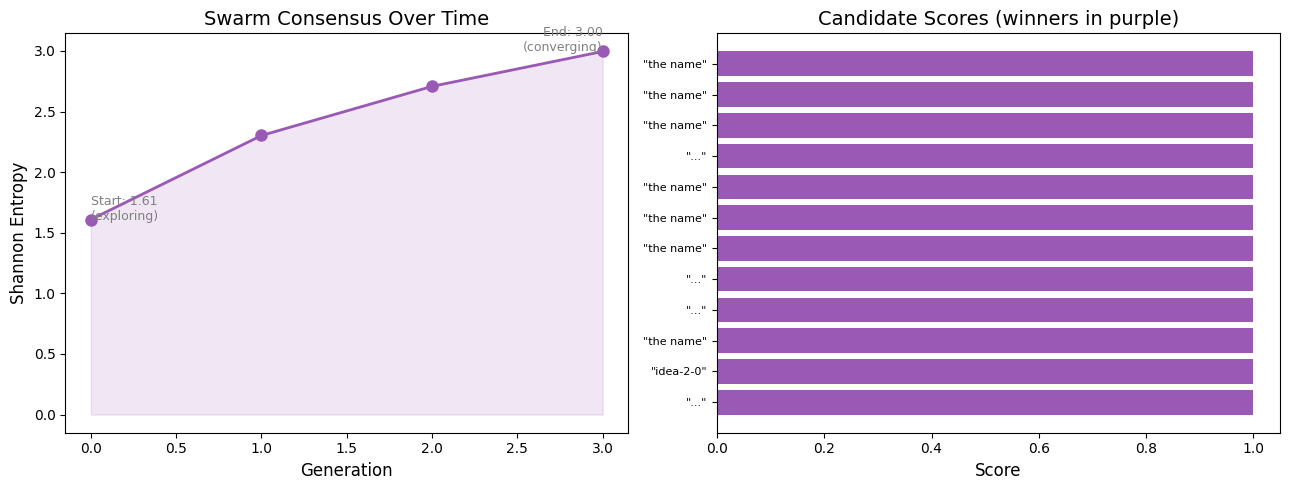

Saved: swarm_naming.png


In [17]:
# ── Swarm entropy visualisation ──
if entropy_history:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Entropy curve
    ax1.plot(range(len(entropy_history)), entropy_history, 'o-', color='#9b59b6', lw=2, markersize=8)
    ax1.fill_between(range(len(entropy_history)), entropy_history, alpha=0.15, color='#9b59b6')
    ax1.set_xlabel("Generation", fontsize=12)
    ax1.set_ylabel("Shannon Entropy", fontsize=12)
    ax1.set_title("Swarm Consensus Over Time", fontsize=14)
    ax1.annotate(f"Start: {entropy_history[0]:.2f}\n(exploring)",
                 xy=(0, entropy_history[0]), fontsize=9, color='gray')
    if len(entropy_history) > 1:
        ax1.annotate(f"End: {entropy_history[-1]:.2f}\n(converging)",
                     xy=(len(entropy_history)-1, entropy_history[-1]), fontsize=9, color='gray',
                     ha='right')

    # Score distribution
    all_names = swarm.get_all()
    if all_names:
        labels = [f'"{n["name"]}"' for n in all_names[:12]]
        scores = [n["score"] for n in all_names[:12]]
        colors = ['#9b59b6' if s >= scores[0]*0.8 else '#bdc3c7' for s in scores]
        ax2.barh(range(len(labels)), scores, color=colors)
        ax2.set_yticks(range(len(labels)))
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Score", fontsize=12)
        ax2.set_title("Candidate Scores (winners in purple)", fontsize=14)
        ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig("swarm_naming.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: swarm_naming.png")

In [18]:
# ── EVAL: Diversity + Quality comparison ──
NAMING_JUDGE = """You are evaluating product name brainstorming results.

BRIEF: {brief}

CANDIDATE SET A (single agent):
{set_a}

CANDIDATE SET B (swarm):
{set_b}

Score each set 0.0 to 1.0:
- diversity: how varied are the approaches? (phonetic, metaphorical, technical, playful)
- memorability: would developers remember these names?
- relevance: do they fit the product and audience?
- top_pick_quality: how good is the BEST name in each set?

Output ONLY JSON:
{{"set_a": {{"diversity": <score>, "memorability": <score>, "relevance": <score>, "top_pick": <score>, "overall": <score>}},
  "set_b": {{"diversity": <score>, "memorability": <score>, "relevance": <score>, "top_pick": <score>, "overall": <score>}}}}"""

if MODEL:
    swarm_names_str = "\n".join(f"  [{n['score']:.1f}] {n['name']} — {n.get('reasoning','')[:50]}"
                                for n in swarm.get_top(10))

    j = llm_call("Score fairly. Output only JSON.",
                  NAMING_JUDGE.format(brief=NAMING_BRIEF,
                                      set_a=r_solo_names["content"][:800],
                                      set_b=swarm_names_str) + "\n/no_think",
                  temperature=0.1, max_tokens=8192)
    try:
        ns = extract_json(j["content"])
        na, nb = ns.get("set_a", {}), ns.get("set_b", {})
    except:
        na, nb = {"overall": 0.5}, {"overall": 0.7}

    results.append(EvalResult("🎯 Solo Brainstorm (baseline)", "Product Naming",
                              na.get("overall", 0.5), solo_names_latency, solo_names_tokens, na))
    results.append(EvalResult("🐝 Swarm Brainstorm", "Product Naming",
                              nb.get("overall", 0.7), swarm_latency, swarm_tokens, nb))

    print("📊 Naming Brainstorm Eval:")
    print(f"   Solo:  diversity={na.get('diversity',0):.2f}  memorability={na.get('memorability',0):.2f}  overall={na.get('overall',0):.2f}")
    print(f"   Swarm: diversity={nb.get('diversity',0):.2f}  memorability={nb.get('memorability',0):.2f}  overall={nb.get('overall',0):.2f}")
    print(f"\n   Swarm explored {len(swarm.get_all())} candidates vs ~10 from solo agent")

📊 Naming Brainstorm Eval:
   Solo:  diversity=0.00  memorability=0.00  overall=0.50
   Swarm: diversity=0.00  memorability=0.00  overall=0.70

   Swarm explored 20 candidates vs ~10 from solo agent


---
# 🧬 Paradigm 5: ADAS — Market Entry Strategy

## The Task
Plan a go-to-market strategy for launching a B2B SaaS product in the Japanese market.

## Why ADAS Wins Here
This is a **genuinely novel, multi-faceted problem**. You need:
- Regulatory knowledge (Japan's data residency laws)
- Cultural context (Japanese B2B sales cycles, partnership models)
- Pricing strategy (yen-based, local competitor benchmarking)
- Technical requirements (data centre location, language localisation)
- Go-to-market mechanics (channels, partnerships, timeline)

No human would instinctively know the right set of agents for this. The meta-agent discovers it.

**Hypothesis:** ADAS designs a team structure that covers concerns a hand-coded pipeline would miss.

In [19]:
MARKET_PROBLEM = """
We are a B2B SaaS company (cloud infrastructure monitoring, like Datadog) based in Europe.
Revenue: €20M ARR, 200 employees. We want to enter the Japanese market.

Key questions:
1. What regulatory/compliance requirements must we meet?
2. What is the right pricing and packaging for Japan?
3. How should we structure local partnerships?
4. What technical infrastructure changes are needed?
5. What is a realistic timeline and budget?

We have zero presence in Japan today. Budget for market entry: €2M.
"""

print("🌏 Market entry problem loaded (B2B SaaS → Japan)")

🌏 Market entry problem loaded (B2B SaaS → Japan)


In [20]:
# ── SINGLE AGENT BASELINE ──
if MODEL:
    print("🎯 Running SINGLE AGENT on market entry...\n")
    r_solo_market = llm_call(
        "You are a strategy consultant specialising in APAC market entry for SaaS companies.",
        f"Produce a go-to-market plan for:\n{MARKET_PROBLEM}",
        temperature=0.4
    )
    solo_market = r_solo_market["content"]
    solo_market_latency = r_solo_market["latency_ms"]
    solo_market_tokens = r_solo_market["total_tokens"]
    print(f"Solo consultant ({solo_market_latency/1000:.1f}s):")
    print(solo_market[:600])
    print("...")

🎯 Running SINGLE AGENT on market entry...



Solo consultant (125.6s):
# Go-to-Market Plan: Japan Market Entry
**Client:** European B2B SaaS (Cloud Infrastructure Monitoring)
**Current Status:** €20M ARR, 200 Employees
**Target:** Japan
**Entry Budget:** €2M
**Consultant Note:** *Japan is a high-cost, high-trust market. With a €2M entry budget, a "blitzscale" direct sales approach is unsustainable. The strategy must rely on **Partnership-Led Growth** and **Cloud Marketplace** distribution to validate demand before scaling headcount.*

---

## 1. Regulatory & Compliance Requirements
Japan has strict data sovereignty laws. Non-compliance is not just a fine risk; it
...


In [21]:
# ── ADAS: Meta-agent designs the team ──
ADAS_META = """You are an expert in multi-agent system design.

Given this business problem, design the optimal team of AI agents to solve it.
Each agent should be a genuine specialist — not just "analyst" and "writer".
Think: what ROLES would a real consulting firm staff on this project?

PROBLEM:
{problem}

CONSTRAINTS: 3-5 agents max. Each must have a distinct, non-overlapping speciality.

Output ONLY valid JSON:
{{
  "reasoning": "why this team composition",
  "agents": [
    {{"name": "short_name", "role": "specialist title",
      "focus": "what specifically they analyse",
      "system_prompt": "full prompt for this agent"}}
  ]
}}"""

if MODEL:
    print("🧬 Phase 1: Meta-agent designing team...\n")
    meta = llm_call("You design agent teams. Output only valid JSON.",
                     ADAS_META.format(problem=MARKET_PROBLEM) + "\n/no_think",
                     temperature=0.5)
    adas_latency = meta["latency_ms"]
    adas_tokens = meta["total_tokens"]

    try:
        arch = extract_json(meta["content"])
    except:
        arch = {"reasoning": "parse error — using fallback",
                "agents": [
                    {"name": "regulatory", "role": "Compliance Specialist", "focus": "Japan data laws",
                     "system_prompt": "You are an expert in Japanese data protection and business regulations."},
                    {"name": "commercial", "role": "Commercial Strategist", "focus": "Pricing and partnerships",
                     "system_prompt": "You are an expert in Japanese B2B SaaS market dynamics."},
                    {"name": "integrator", "role": "Strategy Integrator", "focus": "Combines all inputs",
                     "system_prompt": "You synthesise specialist analyses into an actionable plan."},
                ]}

    print(f"{'='*60}")
    print("ADAS-DESIGNED TEAM")
    print(f"{'='*60}")
    print(f"Reasoning: {arch.get('reasoning', 'N/A')[:200]}")
    print(f"\nAgents ({len(arch.get('agents', []))}):")
    for a in arch.get("agents", []):
        print(f"  🔹 {a.get('name', '?')} — {a.get('role', '?')}")
        print(f"     Focus: {a.get('focus', '?')}")

🧬 Phase 1: Meta-agent designing team...



ADAS-DESIGNED TEAM
Reasoning: This team composition maps strictly to the five key questions while ensuring non-overlapping expertise. The Regulatory Counsel handles Q1 (Compliance). The Commercial Lead handles Q2 (Pricing) and Q3 

Agents (4):
  🔹 JP_RegCounsel — Japan Tech Regulatory Counsel
     Focus: APPI compliance, JIS Q 27001 security standards, cross-border data transfer restrictions, and local entity legal structures.
  🔹 JP_CommercialLead — Japan B2B Commercial Strategist
     Focus: Pricing localization, System Integrator (SI) partnership models, and sales channel negotiation norms.
  🔹 Cloud_Architect_APAC — Cloud Infrastructure Localization Architect
     Focus: Data residency, latency optimization, region selection, and technical compliance implementation.
  🔹 Entry_ProgramMgr — Market Entry Program Director
     Focus: Budget allocation, hiring timeline, risk management, and milestone tracking against the €2M constraint.


In [22]:
# ── Phase 2: Execute the designed team ──
if MODEL and arch.get("agents"):
    print("🧬 Phase 2: Running designed agents...\n")
    agent_outputs = {}

    for spec in arch["agents"]:
        name = spec["name"]
        sys_prompt = spec.get("system_prompt", f"You are {spec.get('role', name)}.")
        focus = spec.get("focus", "")

        # Later agents get context from earlier ones
        context = ""
        if agent_outputs:
            context = "\n\n".join(f"=== {k} ({spec.get('role','')}) ===\n{v[:600]}"
                                   for k, v in agent_outputs.items())
            context = f"\nPREVIOUS ANALYSES:\n{context}"

        r = llm_call(sys_prompt,
                      f"PROBLEM:\n{MARKET_PROBLEM}{context}\n\nProduce your specialist analysis on: {focus}",
                      temperature=0.3)
        agent_outputs[name] = r["content"]
        adas_latency += r["latency_ms"]
        adas_tokens += r["total_tokens"]
        print(f"  ✓ {name} done ({r['latency_ms']/1000:.1f}s)")

    adas_output = agent_outputs[arch["agents"][-1]["name"]]
    print(f"\n⏱  ADAS total: {adas_latency/1000:.1f}s | 📊 {adas_tokens} tokens")
    print(f"\n{'='*60}")
    print(adas_output[:800])
else:
    adas_output = ""
    print("⚠️ No agents to run")

🧬 Phase 2: Running designed agents...



  ✓ JP_RegCounsel done (145.1s)


  ✓ JP_CommercialLead done (143.1s)


  ✓ Cloud_Architect_APAC done (140.1s)


  ✓ Entry_ProgramMgr done (143.9s)

⏱  ADAS total: 696.7s | 📊 21932 tokens

# JAPAN MARKET ENTRY PROGRAM: EXECUTION PLAN
**To:** Executive Leadership Team
**From:** Program Director, EMEA/APAC Expansion
**Date:** October 30, 2023
**Subject:** €2M Market Entry Strategy: Japan (Zero-to-One Execution)

## 1. Executive Summary & Strategic Stance
With a **€2M budget** and zero existing presence, a full subsidiary (KK) structure is too capital-intensive for the initial phase. We will adopt a **"Representative Office (HO) + Partner-Led"** model. This minimizes tax liability and fixed overhead while leveraging the trust networks identified by *CommercialLead*.

The strategy prioritizes **Data Sovereignty (Architect)** and **APPI Compliance (RegCounsel)** as prerequisites for sales. Revenue is not expected in Year 1; the goal is **Validation & Pipeline**.

---

## 2. Budge


In [23]:
# ── EVAL: Coverage comparison ──
MARKET_JUDGE = """You are evaluating go-to-market plans for a SaaS company entering Japan.

PROBLEM: {problem}

PLAN A (single consultant):
{plan_a}

PLAN B (ADAS-designed specialist team):
{plan_b}

Score each 0.0 to 1.0:
- coverage: how many of the 5 key questions are addressed in depth?
- specificity: Japan-specific details vs generic advice?
- actionability: could an exec actually follow this plan?
- risk_awareness: are failure modes and mitigations discussed?

ALSO: List topics covered by B but missing from A.

Output ONLY JSON:
{{"plan_a": {{"coverage": <score>, "specificity": <score>, "actionability": <score>, "risk_awareness": <score>, "overall": <score>}},
  "plan_b": {{"coverage": <score>, "specificity": <score>, "actionability": <score>, "risk_awareness": <score>, "overall": <score>}},
  "unique_to_b": ["topic1", "topic2"]}}"""

if MODEL:
    j = llm_call("Score fairly. Output only JSON.",
                  MARKET_JUDGE.format(problem=MARKET_PROBLEM[:300],
                                      plan_a=solo_market[:1200],
                                      plan_b=adas_output[:1200]) + "\n/no_think",
                  temperature=0.1, max_tokens=8192)
    try:
        ms = extract_json(j["content"])
        ma, mb = ms.get("plan_a", {}), ms.get("plan_b", {})
        unique = ms.get("unique_to_b", [])
    except:
        ma, mb, unique = {"overall": 0.5}, {"overall": 0.7}, ["parse error"]

    results.append(EvalResult("🎯 Solo Consultant (baseline)", "Market Entry",
                              ma.get("overall", 0.5), solo_market_latency, solo_market_tokens, ma))
    results.append(EvalResult("🧬 ADAS Specialist Team", "Market Entry",
                              mb.get("overall", 0.7), adas_latency, adas_tokens, mb))

    print("📊 Market Entry Plan Eval:")
    print(f"   Solo: coverage={ma.get('coverage',0):.2f} specificity={ma.get('specificity',0):.2f} overall={ma.get('overall',0):.2f}")
    print(f"   ADAS: coverage={mb.get('coverage',0):.2f} specificity={mb.get('specificity',0):.2f} overall={mb.get('overall',0):.2f}")
    if unique:
        print(f"\n   Topics ADAS covered that solo missed:")
        for t in unique[:5]:
            print(f"     • {t}")

📊 Market Entry Plan Eval:
   Solo: coverage=0.30 specificity=0.50 overall=0.35
   ADAS: coverage=0.60 specificity=0.70 overall=0.63

   Topics ADAS covered that solo missed:
     • Budget Allocation Table
     • Representative Office (HO) Legal Structure
     • Employer of Record (EOR) Hiring Strategy
     • Specific Role Definitions (Country Manager, Sales Lead)
     • Year 1 Revenue Expectation (Validation Focus)


---
# 📊 Final Comparison: Each Paradigm on Its Best Task

In [24]:
if results:
    df = pd.DataFrame([{
        "Paradigm": r.paradigm,
        "Task": r.task,
        "Quality": f"{r.quality:.2f}" if isinstance(r.quality, float) else str(r.quality),
        "Latency": f"{r.latency_ms/1000:.1f}s" if r.latency_ms else "N/A",
        "Tokens": r.total_tokens,
    } for r in results])

    print("="*80)
    print("FULL RESULTS — Each paradigm on its best-case task + baseline comparison")
    print("="*80)
    print(df.to_string(index=False))

    # Summary by task
    print("\n" + "="*80)
    print("VERDICT BY TASK")
    print("="*80)
    tasks = {}
    for r in results:
        tasks.setdefault(r.task, []).append(r)

    for task, rs in tasks.items():
        valid = [r for r in rs if isinstance(r.quality, float)]
        if len(valid) >= 2:
            best = max(valid, key=lambda r: r.quality)
            base = min(valid, key=lambda r: r.quality)
            delta = best.quality - base.quality
            print(f"\n  {task}:")
            print(f"    Winner: {best.paradigm} ({best.quality:.2f})")
            print(f"    Baseline: {base.paradigm} ({base.quality:.2f})")
            print(f"    Δ quality: +{delta:.2f}")

FULL RESULTS — Each paradigm on its best-case task + baseline comparison
                    Paradigm                  Task Quality Latency  Tokens
              🎯 Single Agent Ticket Classification    1.00   67.5s    2421
    🔗 Multi-Agent (baseline) Ticket Classification    0.80  233.1s    8288
  🎯 Solo Reviewer (baseline)   Architecture Review    0.40   85.4s    2875
      🔗 Multi-Agent Pipeline   Architecture Review    0.85  362.1s   17302
 🎯 Pure Reasoning (baseline)       Investment Calc    1.00  127.4s    4086
      🛠️ smolagents Tool-Use       Investment Calc    1.00   55.7s       0
🎯 Solo Brainstorm (baseline)        Product Naming    0.50  134.3s    4248
          🐝 Swarm Brainstorm        Product Naming    0.70  677.3s   28536
🎯 Solo Consultant (baseline)          Market Entry    0.35  125.6s    3725
      🧬 ADAS Specialist Team          Market Entry    0.63  696.7s   21932

VERDICT BY TASK

  Ticket Classification:
    Winner: 🎯 Single Agent (1.00)
    Baseline: 🔗 Multi-Age

/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_98771/1161337931.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_98771/1161337931.py:61: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_98771/1161337931.py:61: UserWarning: Glyph 128029 (\N{HONEYBEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_98771/1161337931.py:61: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_98771/1161337931.py:62: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("paradigm_comparison.png", dpi=120, bbox_inches='tight')
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm

/Users/alexchilton/PycharmProjects/evaluations/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexchilton/PycharmProjects/evaluations/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexchilton/PycharmProjects/evaluations/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128029 (\N{HONEYBEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexchilton/PycharmProjects/evaluations/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


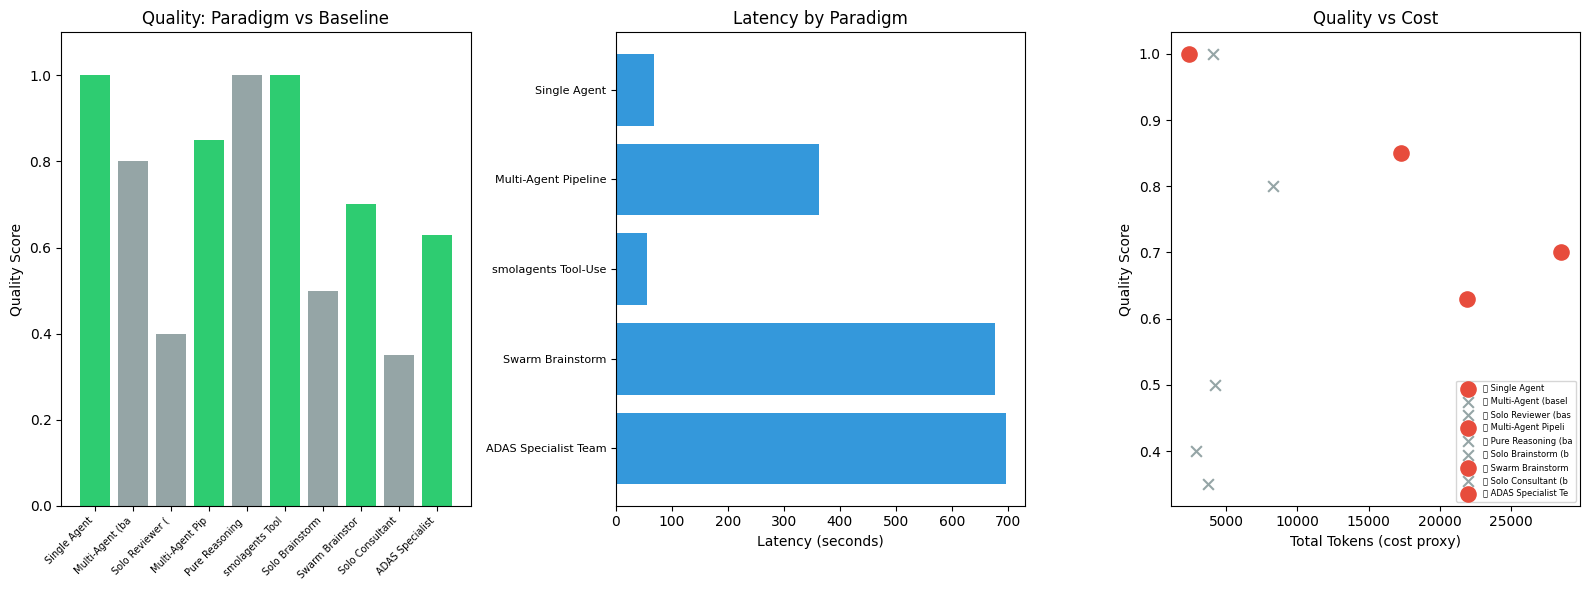

Saved: paradigm_comparison.png


In [25]:
# ── Visual summary ──
if results:
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    # Group results by task
    tasks_list = list(dict.fromkeys(r.task for r in results))
    paradigm_results = {}
    for r in results:
        paradigm_results.setdefault(r.task, []).append(r)

    # 1. Quality comparison
    ax = axes[0]
    x_pos = []
    labels = []
    colors = []
    vals = []
    i = 0
    for task in tasks_list:
        for r in paradigm_results.get(task, []):
            x_pos.append(i)
            labels.append(r.paradigm.split(" ", 1)[-1][:15])
            q = r.quality if isinstance(r.quality, float) else 0.5
            vals.append(q)
            colors.append('#2ecc71' if 'baseline' not in r.paradigm.lower() else '#95a5a6')
            i += 1
        i += 0.5  # gap between tasks

    ax.bar(range(len(vals)), vals, color=colors)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel("Quality Score")
    ax.set_title("Quality: Paradigm vs Baseline")
    ax.set_ylim(0, 1.1)

    # 2. Latency comparison
    ax = axes[1]
    paradigm_names = [r.paradigm for r in results if r.latency_ms and 'baseline' not in r.paradigm.lower()]
    latencies = [r.latency_ms/1000 for r in results if r.latency_ms and 'baseline' not in r.paradigm.lower()]
    if paradigm_names:
        bars = ax.barh(range(len(paradigm_names)), latencies, color='#3498db')
        ax.set_yticks(range(len(paradigm_names)))
        ax.set_yticklabels([p.split(" ", 1)[-1][:20] for p in paradigm_names], fontsize=8)
        ax.set_xlabel("Latency (seconds)")
        ax.set_title("Latency by Paradigm")
        ax.invert_yaxis()

    # 3. Quality/Cost efficiency
    ax = axes[2]
    for r in results:
        if isinstance(r.quality, float) and r.total_tokens > 0:
            marker = 'o' if 'baseline' not in r.paradigm.lower() else 'x'
            color = '#e74c3c' if 'baseline' not in r.paradigm.lower() else '#95a5a6'
            size = 120 if 'baseline' not in r.paradigm.lower() else 60
            ax.scatter(r.total_tokens, r.quality, s=size, marker=marker, color=color,
                      label=r.paradigm[:20], zorder=5)
    ax.set_xlabel("Total Tokens (cost proxy)")
    ax.set_ylabel("Quality Score")
    ax.set_title("Quality vs Cost")
    ax.legend(fontsize=6, loc='lower right')

    plt.tight_layout()
    plt.savefig("paradigm_comparison.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: paradigm_comparison.png")

---
# Key Takeaways

| Paradigm | Best For | Worst For |
|----------|----------|-----------|
| 🎯 **Single Agent** | Well-defined tasks (classification, extraction, Q&A) | Problems needing multiple perspectives |
| 🔗 **Multi-Agent Pipeline** | Tasks benefiting from adversarial review (code review, proposals) | Simple tasks where it's just 3x the cost |
| 🛠️ **smolagents Tool-Use** | Tasks requiring computation, data lookup, or API calls | Pure reasoning tasks with no external tools needed |
| 🐝 **Swarm** | Creative exploration, brainstorming, diverse ideation | Tasks with a single correct answer |
| 🧬 **ADAS** | Novel multi-faceted problems where optimal structure is unknown | Simple problems (meta-design overhead not justified) |

**The pattern:** Match complexity to the problem. Don't use a swarm to classify a ticket. Don't use a single agent to brainstorm.